In [1]:
from pathlib import Path
from tempfile import TemporaryDirectory

import matplotlib.pyplot as plt
import numpy as np

import suite2p

In [6]:
# Figure Style settings for notebook.
import matplotlib as mpl
mpl.rcParams.update({
    'axes.spines.left': False,
    'axes.spines.bottom': False,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'legend.frameon': False,
    'figure.subplot.wspace': .01,
    'figure.subplot.hspace': .01,
    'figure.figsize': (18, 13),
    'ytick.major.left': False,
})

from matplotlib import colormaps
jet = colormaps.get_cmap('jet')

#jet = mpl.cm.get_cmap('jet')
jet.set_bad(color='k')

### Outputs from the Suite2p Pipeline

The output parameters can also be found in the "ops.npy" file.  This is especially useful when running the pipeline from the terminal or the graphical interface.  It contains the same data that is output from the python `run_s2p()` function.

In [9]:
import os; import matplotlib.pyplot as plt; import tifffile as tf
path_added = os.path.split(os.path.split(os.getcwd())[0])[0]; os.chdir(path_added); print("Added path:",path_added)

Added path: c:\Users\johnj\SpellmanLab Dropbox\timspellman\Python\John\PySpell\code


In [12]:
import s2pfuns
F, Fneu, spks, stat, ops, iscell, blF = s2pfuns.read_s2p(fpath = r"C:\Users\johnj\SpellmanLab Dropbox\OtherData\Manuscripts\in prep\L6CTopto_panneuronal_experiment\data\subjects\L612_F_RightPFC_L6Chr_PFCgcamp6f_L6PAN\SEDS_day10_optoRec_LBC2_FOV1_p70")

output_op_file = ops

The other files will be used for the visualizations below.

## Visualizations

### Registration

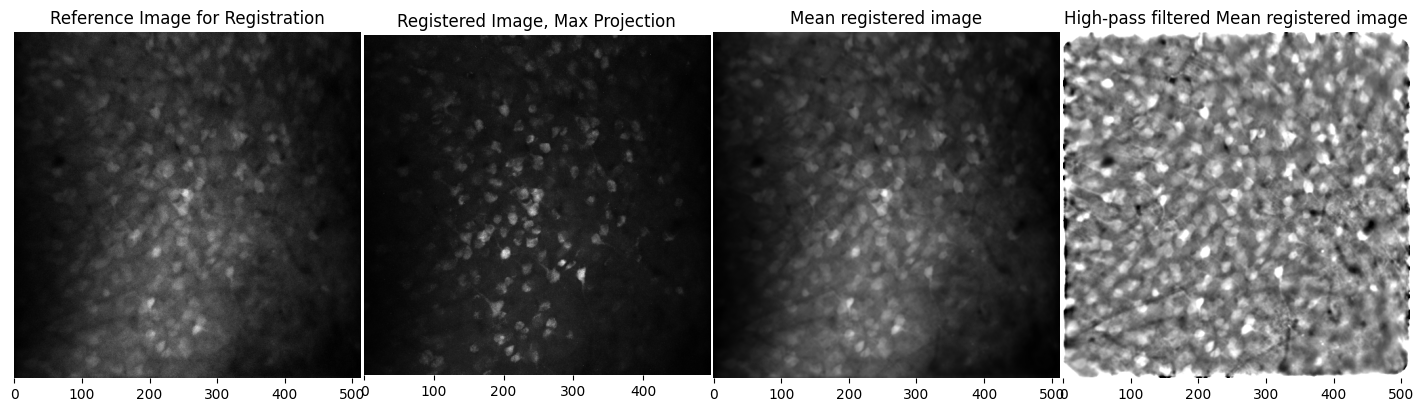

In [13]:
plt.subplot(1, 4, 1)
plt.imshow(ops['refImg'], cmap='gray', )
plt.title("Reference Image for Registration");

plt.subplot(1, 4, 2)
plt.imshow(ops['max_proj'], cmap='gray')
plt.title("Registered Image, Max Projection");

plt.subplot(1, 4, 3)
plt.imshow(ops['meanImg'], cmap='gray')
plt.title("Mean registered image")

plt.subplot(1, 4, 4)
plt.imshow(ops['meanImgE'], cmap='gray')
plt.title("High-pass filtered Mean registered image");

### Detection


C:\Users\johnj\AppData\Local\Temp\ipykernel_41768\3454591365.py:9: RuntimeWarning: All-NaN slice encountered
  plt.imshow(np.nanmax(im[iscell], axis=0), cmap='jet')


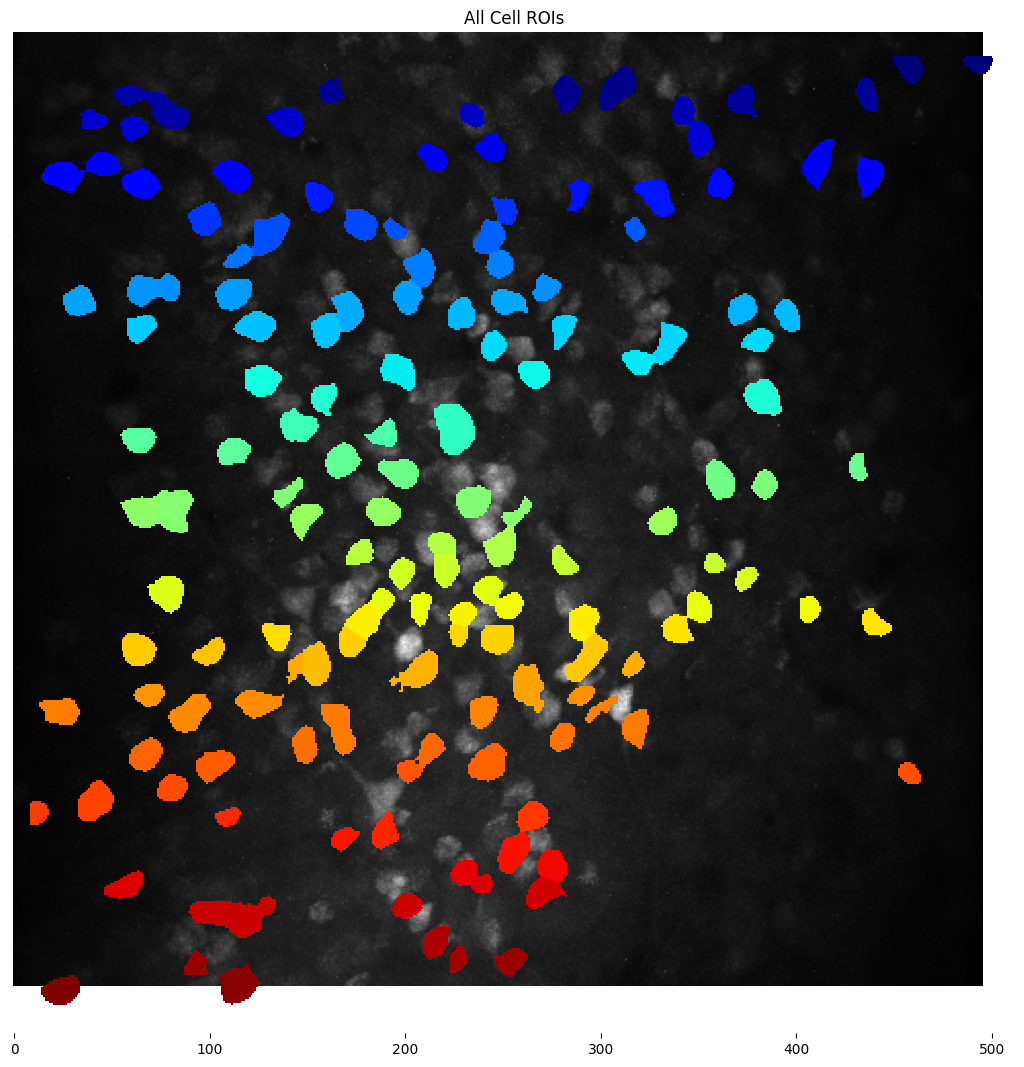

In [18]:
im = suite2p.ROI.stats_dicts_to_3d_array(stat, Ly=ops['Ly'], Lx=ops['Lx'], label_id=True)
im[im == 0] = np.nan

#plt.subplot(1, 4, 1)
plt.imshow(ops['max_proj'], cmap='gray')
#plt.title("Registered Image, Max Projection")

#plt.subplot(1, 4, 4)
plt.imshow(np.nanmax(im[iscell], axis=0), cmap='jet')
plt.title("All Cell ROIs");

Padded max_proj shape: (512, 512)
meanImgE shape: (512, 512)


C:\Users\johnj\AppData\Local\Temp\ipykernel_41768\287653468.py:26: RuntimeWarning: All-NaN slice encountered
  plt.imshow(np.nanmax(im[iscell], axis=0), cmap='jet', alpha=0.6)


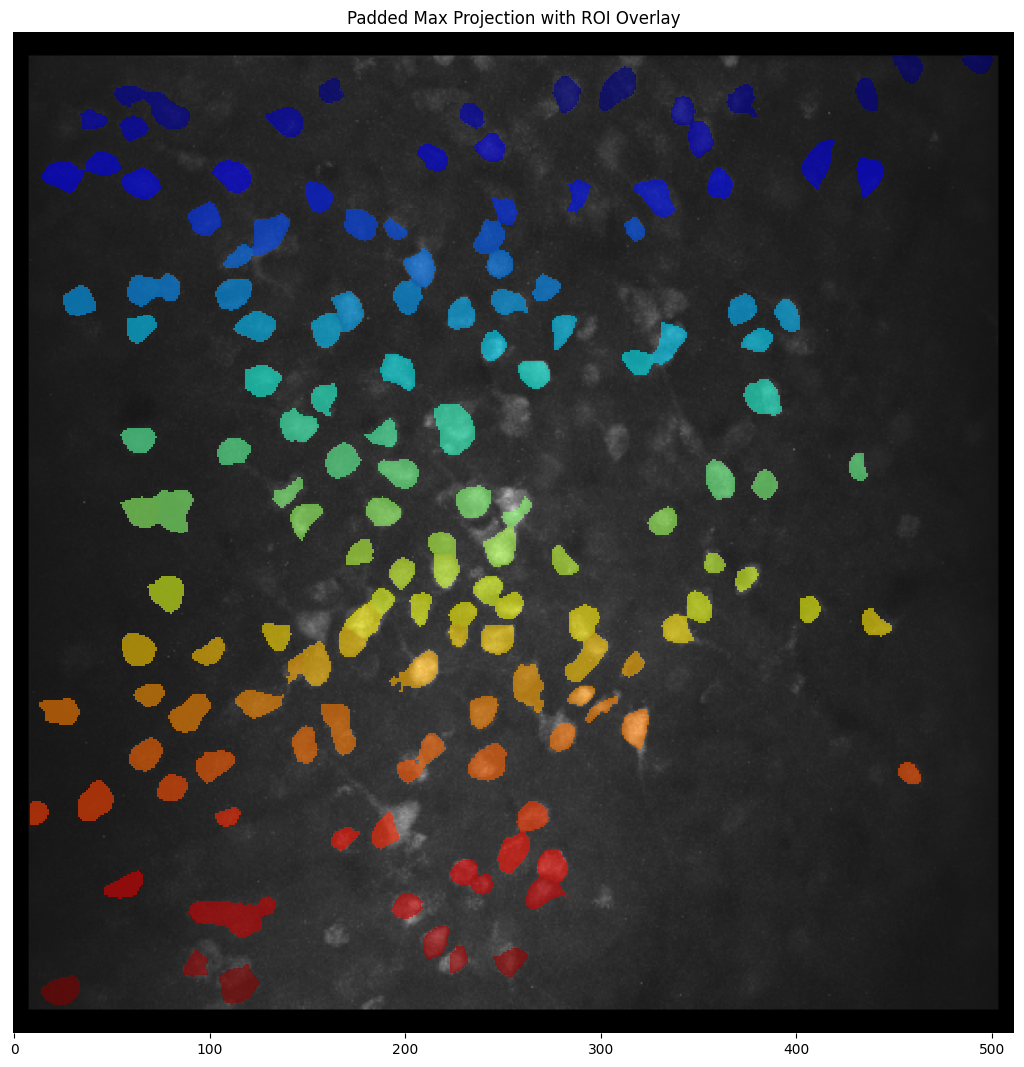

In [19]:
import numpy as np

# Sizes of the images
max_proj = ops['max_proj']
meanImgE = ops['meanImgE']

# Calculate the padding needed
pad_y = (meanImgE.shape[0] - max_proj.shape[0]) // 2
pad_x = (meanImgE.shape[1] - max_proj.shape[1]) // 2

# Apply the padding
padded_max_proj = np.pad(max_proj, ((pad_y, pad_y), (pad_x, pad_x)), mode='constant', constant_values=0)

# If dimensions are odd, add one extra row or column to match exactly
if padded_max_proj.shape[0] != meanImgE.shape[0]:
    padded_max_proj = np.pad(padded_max_proj, ((1, 0), (0, 0)), mode='constant', constant_values=0)
if padded_max_proj.shape[1] != meanImgE.shape[1]:
    padded_max_proj = np.pad(padded_max_proj, ((0, 0), (1, 0)), mode='constant', constant_values=0)

# Verify dimensions
print("Padded max_proj shape:", padded_max_proj.shape)
print("meanImgE shape:", meanImgE.shape)

# Overlay the images
plt.imshow(padded_max_proj, cmap='gray')
plt.imshow(np.nanmax(im[iscell], axis=0), cmap='jet', alpha=0.6)
plt.title("Padded Max Projection with ROI Overlay")
plt.show()


C:\Users\johnj\AppData\Local\Temp\ipykernel_41768\1669927327.py:9: RuntimeWarning: All-NaN slice encountered
  plt.imshow(np.nanmax(im, axis=0), cmap='jet')
C:\Users\johnj\AppData\Local\Temp\ipykernel_41768\1669927327.py:13: RuntimeWarning: All-NaN slice encountered
  plt.imshow(np.nanmax(im[~iscell], axis=0, ), cmap='jet')
C:\Users\johnj\AppData\Local\Temp\ipykernel_41768\1669927327.py:17: RuntimeWarning: All-NaN slice encountered
  plt.imshow(np.nanmax(im[iscell], axis=0), cmap='jet')


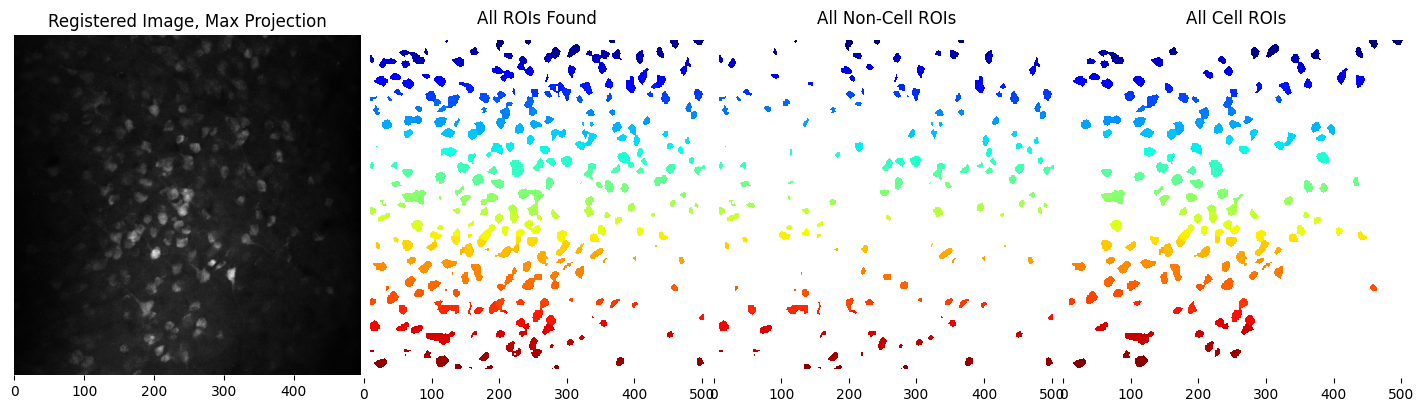

In [14]:
im = suite2p.ROI.stats_dicts_to_3d_array(stat, Ly=ops['Ly'], Lx=ops['Lx'], label_id=True)
im[im == 0] = np.nan

plt.subplot(1, 4, 1)
plt.imshow(ops['max_proj'], cmap='gray')
plt.title("Registered Image, Max Projection")

plt.subplot(1, 4, 2)
plt.imshow(np.nanmax(im, axis=0), cmap='jet')
plt.title("All ROIs Found")

plt.subplot(1, 4, 3)
plt.imshow(np.nanmax(im[~iscell], axis=0, ), cmap='jet')
plt.title("All Non-Cell ROIs")

plt.subplot(1, 4, 4)
plt.imshow(np.nanmax(im[iscell], axis=0), cmap='jet')
plt.title("All Cell ROIs");


## Extract Traces


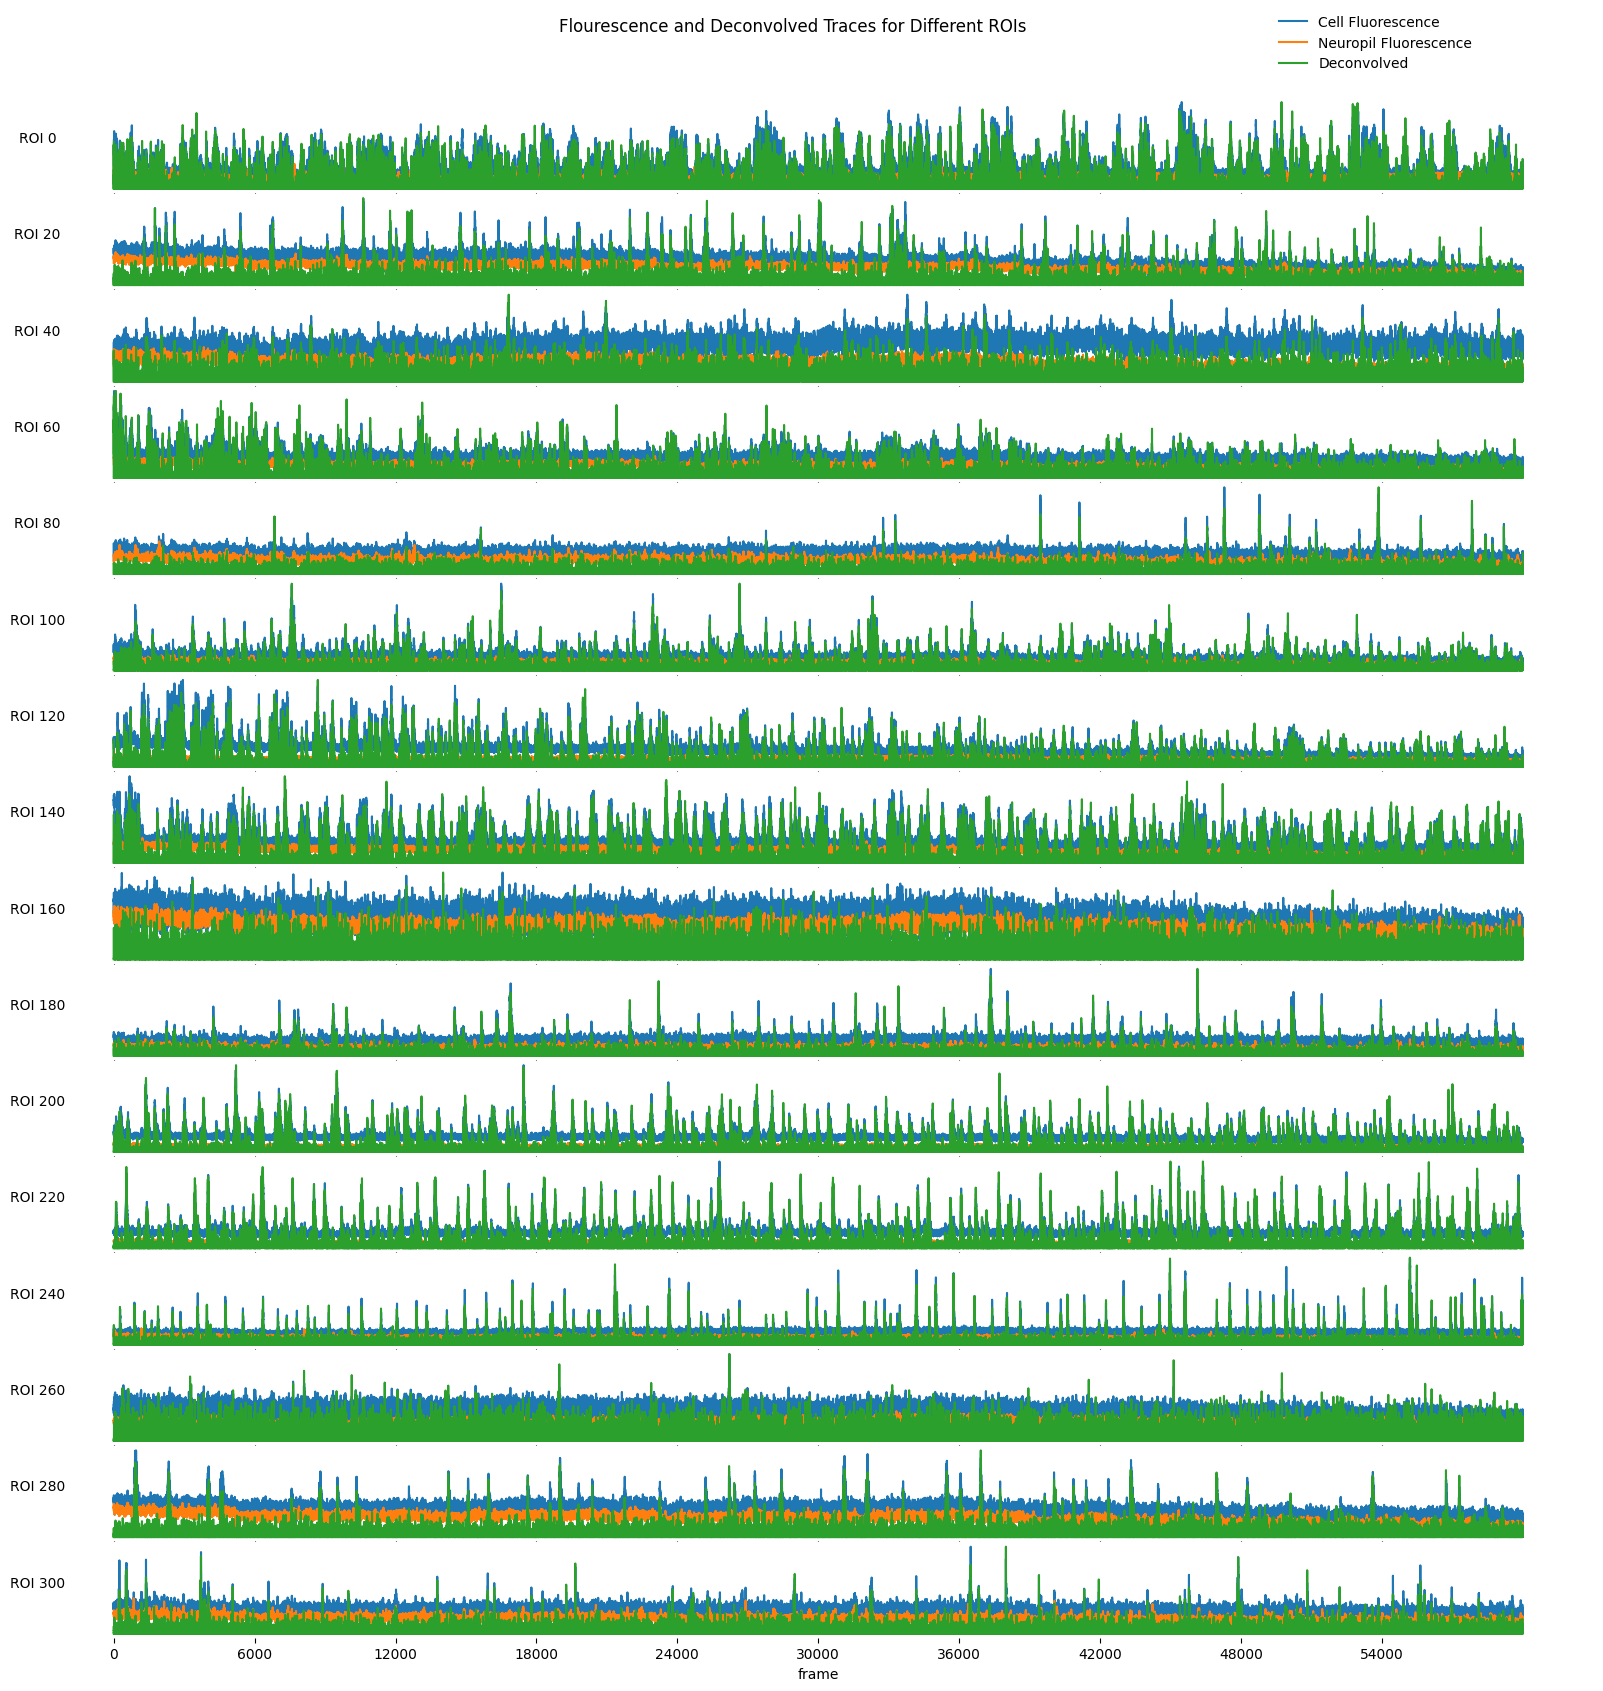

In [17]:
plt.figure(figsize=[20,20])
plt.suptitle("Flourescence and Deconvolved Traces for Different ROIs", y=0.92);
rois = np.arange(len(F))[::20]
for i, roi in enumerate(rois):
    plt.subplot(len(rois), 1, i+1, )
    f = F[roi]
    f_neu = Fneu[roi]
    sp = spks[roi]
    # Adjust spks range to match range of fluroescence traces
    fmax = np.maximum(f.max(), f_neu.max())
    fmin = np.minimum(f.min(), f_neu.min())
    frange = fmax - fmin 
    sp /= sp.max()
    sp *= frange
    plt.plot(f, label="Cell Fluorescence")
    plt.plot(f_neu, label="Neuropil Fluorescence")
    plt.plot(sp + fmin, label="Deconvolved")
    plt.xticks(np.arange(0, F.shape[1], F.shape[1]/10))
    plt.ylabel(f"ROI {roi}", rotation=0)
    plt.xlabel("frame")
    if i == 0:
        plt.legend(bbox_to_anchor=(0.93, 2))